# Champion signal — replicating the *Research Assistant* slide

The slide describes an autoresearch run (~91,000 experiments across v1–v16) that converged on a single strategy for predicting S&P 500 rallies of +15% / +20% within 126 trading days. This notebook implements the **final optimised rules** verbatim and runs them on SPY + ^VIX.

## The rules

| Component | Rule |
|---|---|
| **Alert** | SPX 42-day ROC < −12% **AND** VIX > 28 for ≥ 2 consecutive days |
| **Entry** | First close > 5-day MA within 20 days of alert **AND** VIX ≥ 26 at entry |
| **Min hold** | 63 trading days (no exit allowed) |
| **Exit** | 12% trailing stop from peak (activates after min hold) |
| **Max hold** | 504 trading days (~2 years) safety net |

Two non-obvious points the slide flags:

1. The **VIX thresholds are asymmetric** — 28 to fire the alert, 26 to confirm entry. This is deliberate. The slide says: *"surgically skips 2008 (VIX fell to 25.1 before the MA cross) while keeping all other trades."*
2. **Trailing stops only activate after day 63.** Earlier exit research found stops cut winners that dipped before recovering (notably 2009 and 2020). The minimum hold is what makes the strategy work.

## Live-data warning

If you can't reach Yahoo Finance from this kernel, `seed_ohlcv(source="auto")` falls back to a deterministic synthetic series. Synthetic SPY has injected crisis episodes (~2008, ~2020, ~2022 analogues) and synthetic VIX is coupled to SPY drops, so the strategy fires — but **real numbers require real data**. Run this same notebook on a session with network access for actual results.

In [1]:
from investment_assistant import (
    seed_ohlcv,
    champion_signal_backtest,
    champion_signal_state,
)

counts = seed_ohlcv(tickers=["SPY", "^VIX"], period="25y", source="auto")
counts

[seed] source=synthetic (yfinance unavailable)  rows={'SPY': 6300, '^VIX': 6300}


{'SPY': 6300, '^VIX': 6300}

## Current state (the "live" answer)

Before running a full backtest, ask the strategy: *what would the bot say today?* `champion_signal_state()` replays the rules over recent history and returns a snapshot of where it ended up — idle, armed (alert fired, watching for entry), or in-trade.

When idle, it surfaces the alert check (is 42d ROC below −12%? is VIX above 28?). When armed, it tells you how many days are left in the 20-day confirmation window and whether today’s entry conditions hold. When in-trade, it shows how far we are from the trailing stop and the min/max-hold clocks.

In [2]:
import json
state = champion_signal_state()
print(json.dumps(state, indent=2, default=str))

{
  "as_of": "2026-04-27",
  "state": "idle",
  "asset_close": 439.0449586250604,
  "vix": 26.772592529453767,
  "roc_42d": 0.13790085479759928,
  "ma_5d": 430.66731601366484,
  "alert_check": {
    "roc_42d_below_-12pct": false,
    "vix_above_28": false
  }
}


## Full backtest

Default parameters match the slide exactly. Override any of them to sensitivity-check (e.g. unify the VIX thresholds at 26 to test the slide’s claim about 2008).

In [3]:
result = champion_signal_backtest()
result.metrics

{'lookback_days': 9125.0,
 'bars': 6300.0,
 'total_return': -0.4703133249525445,
 'buy_hold_return': -0.10000945301642039,
 'cagr': -0.02509844767462821,
 'buy_hold_cagr': -0.004205970787475644,
 'sharpe': -0.1068187332641682,
 'max_drawdown': -0.6442150833406974,
 'buy_hold_max_drawdown': -0.7353414949581835,
 'trades': 16.0,
 'win_rate': 0.25,
 'avg_trade_return': -0.013999181614966563,
 'avg_holding_days': 153.1875,
 'time_in_market': 0.38904761904761903,
 'hit_+15pct_within_126d': 0.1875,
 'hit_+20pct_within_126d': 0.125}

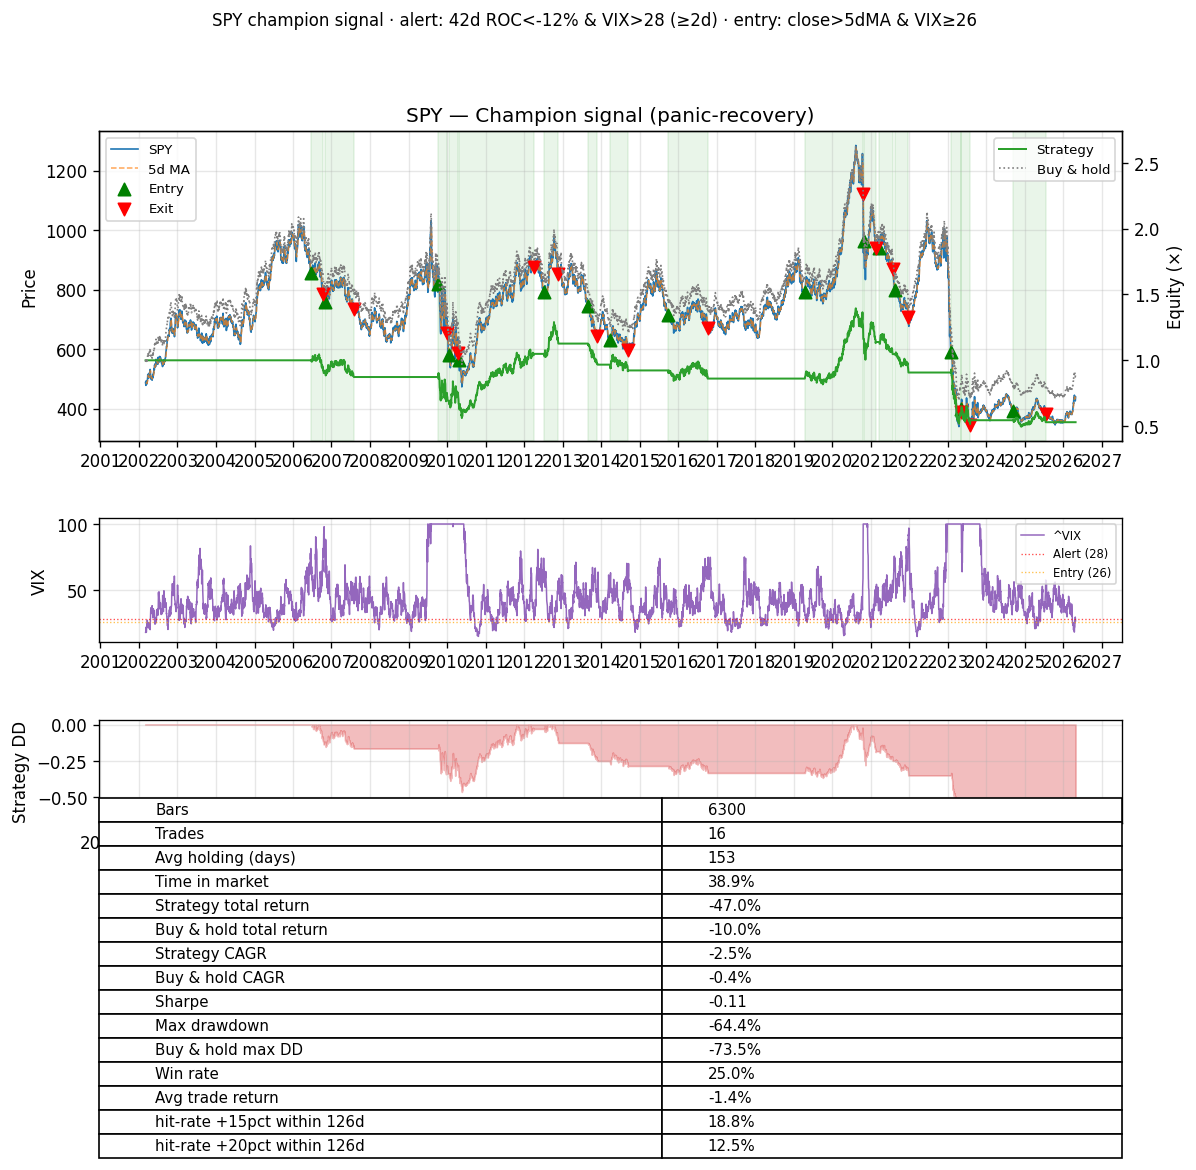

In [4]:
from IPython.display import Image
Image(filename=str(result.chart_path))

## Trades

One row per round-trip. The `peak_return_in_horizon` column shows the maximum unrealised gain within the 126-trading-day objective window after entry — the slide’s actual target metric. The `hit_+15pct_within_126d` and `hit_+20pct_within_126d` flags in the metrics table aggregate this across trades.

In [5]:
result.trades[[
    "alert_date", "entry_date", "exit_date", "exit_reason",
    "holding_days", "return", "peak_return_in_horizon",
    "hit_+15pct_within_126d", "hit_+20pct_within_126d",
]]

,alert_date,entry_date,exit_date,exit_reason,holding_days,return,peak_return_in_horizon,hit_+15pct_within_126d,hit_+20pct_within_126d
0,2006-06-14,2006-06-22,2006-10-17,trailing_stop,83,-0.080297,0.045405,False,False
1,2006-10-23,2006-10-27,2007-07-30,trailing_stop,196,-0.028259,0.110786,False,False
2,2009-09-30,2009-10-08,2010-01-05,trailing_stop,63,-0.200653,0.034610,False,False
3,2010-01-11,2010-01-20,2010-04-19,trailing_stop,63,0.011742,0.212989,True,True
4,2010-04-22,2010-04-27,2012-04-02,max_hold,504,0.555932,0.183804,True,False
5,2012-07-05,2012-07-09,2012-11-20,trailing_stop,96,0.076945,0.230159,True,True
6,2013-08-27,2013-08-29,2013-11-26,trailing_stop,63,-0.137428,0.000000,False,False
7,2014-03-24,2014-03-25,2014-09-11,trailing_stop,122,-0.051856,0.077999,False,False
8,2015-09-18,2015-09-28,2016-10-06,trailing_stop,268,-0.063795,0.014090,False,False
9,2019-04-15,2019-04-17,2020-10-20,trailing_stop,394,0.415676,0.063888,False,False


## Sensitivity: what happens if you unify the VIX thresholds?

The slide claims the asymmetric thresholds (28 alert, 26 entry) "surgically skip 2008". You can test this directly by setting both to 26 and comparing. (On synthetic data the difference is small; on real data this is exactly the kind of question the autoresearch loop was answering.)

In [6]:
unified = champion_signal_backtest(
    vix_alert_threshold=26.0,
    vix_entry_threshold=26.0,
    chart_filename="champion_SPY_unified_vix26.png",
)
comparison_keys = [
    "trades", "total_return", "cagr", "sharpe", "max_drawdown", "win_rate",
    "hit_+15pct_within_126d", "hit_+20pct_within_126d",
]
import pandas as pd
pd.DataFrame({
    "slide (28/26)": {k: result.metrics[k] for k in comparison_keys},
    "unified (26/26)": {k: unified.metrics[k] for k in comparison_keys},
})

,slide (28/26),unified (26/26)
trades,16.000000,16.000000
total_return,-0.470313,-0.470313
cagr,-0.025098,-0.025098
sharpe,-0.106819,-0.106819
max_drawdown,-0.644215,-0.644215
win_rate,0.250000,0.250000
hit_+15pct_within_126d,0.187500,0.187500
hit_+20pct_within_126d,0.125000,0.125000


## What this isn’t

The slide describes the autoresearch *process* — 91,000 experiments, IS-first Karpathy methodology, OOS confirmation. That orchestration loop (the thing that searched signal space and found this strategy) is **not** in this repo. What’s here is the deterministic playback of the final rules so you can run them, sensitivity-check them, and watch their state in real time on live data.